In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [4]:
import os

os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip_nav.csv',
 'ICICI_Bluechip_nav.csv',
 'Kotak_Bluechip_nav.csv',
 'Nippon_Large_Cap_nav.csv',
 'SBI_Bluechip_nav.csv']

In [8]:
df = pd.read_csv("../data/raw/02_nav_history.csv")
df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [9]:
df.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [11]:
df['amfi_code'].nunique()
df.shape

(46000, 3)

In [12]:
df['date']=pd.to_datetime(df['date'])

In [13]:
df = df.sort_values(['amfi_code','date'])

df['daily_return'] = (
    df.groupby('amfi_code')['nav']
      .pct_change()
)

In [14]:
df.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [15]:
cagr_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    start_nav = temp['nav'].iloc[0]
    end_nav = temp['nav'].iloc[-1]

    years = (
        temp['date'].max() -
        temp['date'].min()
    ).days / 365

    cagr = ((end_nav/start_nav)**(1/years)) - 1

    cagr_results.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=['amfi_code', 'CAGR']
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [16]:
rf = 0.065

sharpe_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    annual_return = temp['daily_return'].mean() * 252

    annual_volatility = temp['daily_return'].std() * np.sqrt(252)

    sharpe = (annual_return - rf) / annual_volatility

    sharpe_results.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code', 'Sharpe']
)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [17]:
rf = 0.065

sharpe_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    annual_return = temp['daily_return'].mean() * 252

    annual_volatility = temp['daily_return'].std() * np.sqrt(252)

    sharpe = (annual_return - rf) / annual_volatility

    sharpe_results.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=['amfi_code', 'Sharpe']
)

sharpe_df.head()

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [18]:
sortino_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund]

    downside = temp[temp['daily_return'] < 0]['daily_return']

    downside_std = downside.std() * np.sqrt(252)

    annual_return = temp['daily_return'].mean() * 252

    sortino = (annual_return - rf) / downside_std

    sortino_results.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=['amfi_code', 'Sortino']
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [19]:
df.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [20]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [22]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark = benchmark.sort_values('date')

benchmark['benchmark_return'] = (
    benchmark['close_value']
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899


In [23]:
df = pd.merge(
    df,
    benchmark[['date','benchmark_return']],
    on='date',
    how='left'
)

df.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,-0.869574
2,100016,2022-01-03,520.4608,NaN,3.261121
3,100016,2022-01-03,520.4608,NaN,-0.850741
4,100016,2022-01-03,520.4608,NaN,11.251899


In [24]:
from scipy.stats import linregress

alpha_beta_results = []

for fund in df['amfi_code'].unique():

    temp = df[df['amfi_code'] == fund].dropna()

    slope, intercept, r, p, se = linregress(
        temp['benchmark_return'],
        temp['daily_return']
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta_results.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=['amfi_code', 'Alpha', 'Beta']
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037661,-0.000003
1,100025,0.044818,-0.000003
2,100033,0.265138,0.000012
3,101206,0.208464,0.000011
4,101207,0.109861,-0.000005


In [25]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

In [ ]:
mdd_results = []
for fund in df['amfi_code'].unique():
    temp = df[df['amfi_code'] == fund]

    running_max = temp['nav'].cummax()
    drawdown = (
        temp['nav'] / running_max
    ) - 1
    max_dd = drawdown.min()
    mdd_results.append(
        [fund, max_dd]
    )
mdd_df = pd.DataFrame(
    mdd_results,
    columns=['amfi_code', 'Max_Drawdown']
)
mdd_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [ ]:
scorecard = cagr_df.merge(
    sharpe_df,
    on='amfi_code'
)
scorecard = scorecard.merge(
    sortino_df,
    on='amfi_code'
)
scorecard = scorecard.merge(
    alpha_beta_df,
    on='amfi_code'
)
scorecard = scorecard.merge(
    mdd_df,
    on='amfi_code'
)
scorecard.head()

,amfi_code,CAGR,Sharpe,Sortino,Alpha,Beta,Max_Drawdown
0,100016,0.026352,-0.201517,-0.351047,0.037661,-0.000003,-0.247344
1,100025,0.044551,-0.567095,-0.941821,0.044818,-0.000003,-0.043083
2,100033,0.300997,1.093699,1.829134,0.265138,0.000012,-0.162172
3,101206,0.235205,1.027213,1.799563,0.208464,0.000011,-0.112916
4,101207,0.079331,0.162661,0.276644,0.109861,-0.000005,-0.354469


In [28]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

In [ ]:
top5 = scorecard.nlargest(
    5,
    'CAGR'
)
top5

,amfi_code,CAGR,Sharpe,Sortino,Alpha,Beta,Max_Drawdown
25,120505,0.328016,1.180101,2.029353,0.278249,0.000025,-0.181885
21,119598,0.323981,0.945308,1.675317,0.295143,0.000013,-0.287060
39,149324,0.322621,0.949796,1.619793,0.296003,0.000008,-0.311719
36,148569,0.319245,1.234930,2.146914,0.295861,-0.000022,-0.163967
34,148567,0.309499,1.448291,2.385644,0.278900,-0.000014,-0.112657


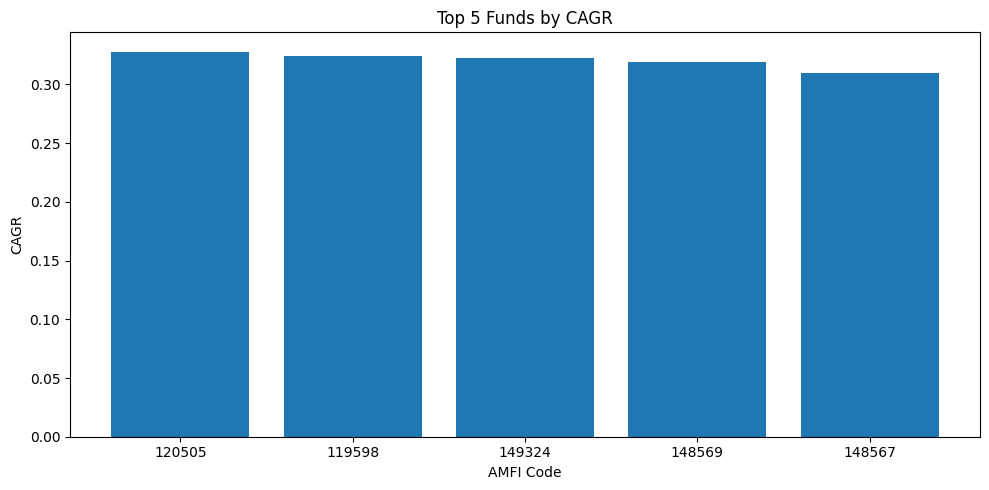

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.bar(
    top5['amfi_code'].astype(str),
    top5['CAGR']
)
plt.title('Top 5 Funds by CAGR')
plt.xlabel('AMFI Code')
plt.ylabel('CAGR')
plt.tight_layout()
plt.savefig(
    "benchmark_comparison.png"
)
plt.show()

In [31]:
import os

os.listdir()

['alpha_beta.csv',
 'benchmark_comparison.png',
 'EDA_Analysis.ipynb',
 'fund_scorecard.csv',
 'Performance_Analytics.ipynb']